# Testy systemu (punkty 6-7):
6. Przeprowadź analizę FAR/FRR względem progu decyzyjnego (threshold) oraz przedstaw krzywą ROC i uzasadnij wybór progu pracy systemu.
7. Zbadaj wpływ kompresji JPEG na skuteczność systemu (minimum trzy poziomy jakości kompresji)

In [1]:
import math
import io
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from sklearn.metrics import auc

In [ ]:
# Ścieżki
BASE_DIR = Path(".")
MODEL_WEIGHTS = BASE_DIR / "results" / "arcface_celeba_best.pth"
IMG_DIR = BASE_DIR / "data" / "img_align_celeba_cropped" / "cropped"
IDENTITY_FILE = BASE_DIR / "data" / "celeba_metadata" / "identity_CelebA.txt"
TEST_SPLIT_FILE = BASE_DIR / "data" / "split" / "test_split.txt"

# Parametry modelu
EMBEDDING_SIZE = 512

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Definicja architektury — IBasicBlock

In [4]:
class IBasicBlock(nn.Module):
    """Blok residualny IResNet (BN-Conv-BN-PReLU-Conv-BN)."""
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(inplanes, eps=1e-05)
        self.conv1 = nn.Conv2d(inplanes, planes, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, eps=1e-05)
        self.prelu = nn.PReLU(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes, eps=1e-05)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.bn1(x)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn3(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return out

## Definicja architektury — IResNet

In [5]:
class IResNet(nn.Module):
    """Improved ResNet for face recognition (insightface architecture).

    Input:  (B, 3, 112, 112)
    Output: (B, embedding_size)  — domyślnie 512
    """
    fc_scale = 7 * 7

    def __init__(self, block, layers, embedding_size=512, dropout=0.0):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(64, eps=1e-05)
        self.prelu = nn.PReLU(64)
        self.layer1 = self._make_layer(block, 64, layers[0], stride=2)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.bn2 = nn.BatchNorm2d(512 * block.expansion, eps=1e-05)
        self.dropout = nn.Dropout(p=dropout, inplace=True)
        self.fc = nn.Linear(512 * block.expansion * self.fc_scale, embedding_size)
        self.features = nn.BatchNorm1d(embedding_size, eps=1e-05)
        nn.init.constant_(self.features.weight, 1.0)
        self.features.weight.requires_grad = False

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0, 0.1)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, 1, stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion, eps=1e-05),
            )
        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.prelu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.bn2(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.features(x)
        return x

## Funkcja fabryczna `iresnet50`

In [6]:
def iresnet50(**kwargs):
    return IResNet(IBasicBlock, [3, 4, 14, 3], **kwargs)

## Ładowanie wytrenowanego modelu

In [7]:
model = iresnet50(embedding_size=EMBEDDING_SIZE)

state_dict = torch.load(MODEL_WEIGHTS, map_location="cpu", weights_only=True)
state_dict = {k: v.float() if v.dtype == torch.float16 else v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

print(f"Model załadowany z: {MODEL_WEIGHTS}")
print(f"Parametry: {sum(p.numel() for p in model.parameters()):,}")

Model załadowany z: results/arcface_celeba_best.pth
Parametry: 43,590,848


## Transformacja obrazów (preprocessing)

In [8]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

## Funkcja ekstrakcji embeddingu

In [9]:
@torch.no_grad()
def get_embedding(model, image_path, transform=preprocess):
    """Zwraca znormalizowany embedding (512-dim) dla pojedynczego obrazu."""
    img = Image.open(image_path).convert("RGB")
    return get_embedding_from_pil(model, img, transform)

@torch.no_grad()
def get_embedding_from_pil(model, img, transform=preprocess):
    tensor = transform(img).unsqueeze(0).to(device)
    emb = model(tensor)
    emb = F.normalize(emb, p=2, dim=1)
    return emb.cpu().squeeze(0)


@torch.no_grad()
def get_embeddings_batch(model, image_paths, transform=preprocess, batch_size=64):
    """Zwraca znormalizowane embeddingi dla listy obrazów."""
    all_emb = []
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i : i + batch_size]
        images = torch.stack([
            transform(Image.open(p).convert("RGB")) for p in batch_paths
        ]).to(device)
        emb = model(images)
        emb = F.normalize(emb, p=2, dim=1)
        all_emb.append(emb.cpu())
    return torch.cat(all_emb, dim=0)

## Weryfikacja 1:1 — porównanie dwóch twarzy

In [10]:
def verify(model, img_path1, img_path2, threshold=0.5):
    """Weryfikacja 1:1 — czy dwa zdjęcia przedstawiają tę samą osobę.

    Args:
        model: wytrenowany backbone IResNet50
        img_path1, img_path2: ścieżki do cropowanych zdjęć (112x112)
        threshold: próg cosine similarity (domyślnie 0.5)

    Returns:
        (is_same: bool, similarity: float)
    """
    emb1 = get_embedding(model, img_path1)
    emb2 = get_embedding(model, img_path2)
    similarity = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
    return similarity >= threshold, similarity

## Przygotowanie danych testowych

In [11]:
# Wczytanie mapowania: filename -> identity_id
file_to_identity = {}
with open(IDENTITY_FILE, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 2:
            continue
        orig_filename, identity_id = parts[0], int(parts[1])
        cropped_name = Path(orig_filename).stem + "_cropped.jpg"
        if (IMG_DIR / cropped_name).exists():
            file_to_identity[cropped_name] = identity_id

# Wczytanie tożsamości ze zbioru testowego
test_ids = set()
with open(TEST_SPLIT_FILE, "r") as f:
    for line in f:
        test_ids.add(int(line.strip()))

# Zbudowanie mapowania identity -> lista plików (tylko test)
identity_to_files = defaultdict(list)
for fname, identity in file_to_identity.items():
    if identity in test_ids:
        identity_to_files[identity].append(fname)

print(f"Tożsamości testowe: {len(identity_to_files)}")
print(f"Obrazów testowych: {sum(len(v) for v in identity_to_files.values())}")

Tożsamości testowe: 1402
Obrazów testowych: 29938


# Analiza FAR/FRR względem progu decyzyjnego (threshold)

In [18]:
# Positive pairs
positive_scores = []

for identity, files in tqdm(identity_to_files.items(), desc="Positive pairs"):
    if len(files) < 2:
        continue
    for i in range(len(files)):
        for j in range(i + 1, min(i+2, len(files))):
            _, sim = verify(model, IMG_DIR / files[i], IMG_DIR / files[j])
            positive_scores.append(sim)

Positive pairs: 100%|██████████| 1402/1402 [06:52<00:00,  3.40it/s]


In [20]:
len(positive_scores), min(positive_scores), max(positive_scores)

(28536, -0.19400854408740997, 1.0000001192092896)

In [ ]:
NUM_PAIRS = len(positive_scores)
ids = list(identity_to_files.keys())
fixed_negative_pairs = []

for _ in range(NUM_PAIRS):
    id1, id2 = random.sample(ids, 2)
    f1 = random.choice(identity_to_files[id1])
    f2 = random.choice(identity_to_files[id2])

    fixed_negative_pairs.append((f1, f2))

len(fixed_negative_pairs)

In [ ]:
# Negative pairs
negative_scores = []

for f1, f2 in tqdm(fixed_negative_pairs, desc="Negative pairs"):
    _, sim = verify(model, IMG_DIR / f1, IMG_DIR / f2)
    negative_scores.append(sim)

Negative pairs: 100%|██████████| 28536/28536 [06:53<00:00, 68.94it/s]


In [22]:
len(negative_scores), min(negative_scores), max(negative_scores)

(28536, -0.3111202120780945, 0.39045172929763794)

In [56]:
with open('far_frr_analysis.json', 'w') as f:
    json.dump({
        'positive_scores': list(positive_scores),
        'negative_scores': list(negative_scores)
    }, f)

In [23]:
thresholds = np.linspace(-1, 1, 200)

far_list = []
frr_list = []

for t in thresholds:
    FAR = np.mean([s >= t for s in negative_scores])
    FRR = np.mean([s < t for s in positive_scores])
    
    far_list.append(FAR)
    frr_list.append(FRR)

In [24]:
diff = np.abs(np.array(far_list) - np.array(frr_list))
eer_index = np.argmin(diff)

eer_threshold = thresholds[eer_index]
eer = far_list[eer_index]

print(f"EER: {eer:.4f} przy threshold={eer_threshold:.4f}")

EER: 0.0303 przy threshold=0.1357


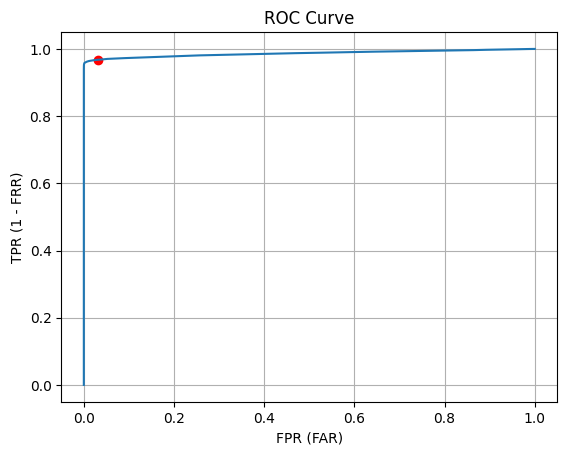

In [34]:
tpr = [1 - f for f in frr_list]
fpr = far_list

plt.plot(fpr, tpr)
plt.scatter(fpr[eer_index], tpr[eer_index], color='red', label='EER')
plt.xlabel("FPR (FAR)")
plt.ylabel("TPR (1 - FRR)")
plt.title("ROC Curve")
plt.grid()
plt.show()

In [33]:
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

AUC: 0.9866


In [36]:
tpr = np.array(tpr)
fpr = np.array(fpr)

# distance to (0, 1)
dist = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)

best_idx = np.argmin(dist)

roc_best_threshold = thresholds[best_idx]
roc_best_fpr = fpr[best_idx]
roc_best_tpr = tpr[best_idx]

print(f"Best point ROC: TPR={roc_best_tpr:.4f}, FPR={roc_best_fpr:.4f}, threshold={roc_best_threshold:.4f}")

Best point ROC: TPR=0.9641, FPR=0.0116, threshold=0.1658


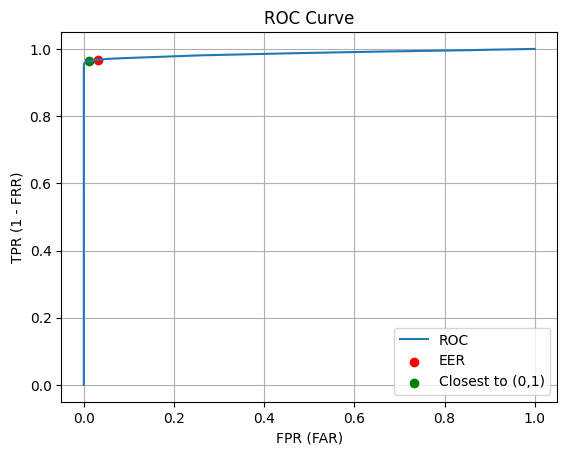

In [39]:
plt.plot(fpr, tpr, label="ROC")
plt.scatter(fpr[eer_index], tpr[eer_index], color='red', label='EER')
plt.scatter(best_fpr, best_tpr, color='green', label='Closest to (0,1)')
plt.xlabel("FPR (FAR)")
plt.ylabel("TPR (1 - FRR)")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

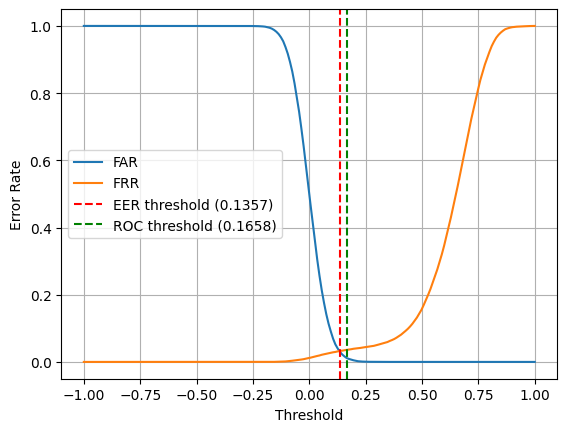

In [40]:
plt.plot(thresholds, far_list, label="FAR")
plt.plot(thresholds, frr_list, label="FRR")
plt.axvline(x=eer_threshold, color='red', linestyle='--', label=f"EER threshold ({eer_threshold:.4f})")
plt.axvline(x=roc_best_threshold, color='green', linestyle='--', label=f"ROC threshold ({roc_best_threshold:.4f})")
plt.xlabel("Threshold")
plt.ylabel("Error Rate")
plt.legend()
plt.grid()
plt.show()

## Przykład wyboru thresholdu

In [28]:
# minimalizacja FAR w celu zwiększenia bezpieczeństwa, np. w bankowości
target_far = 0.001
idx = np.argmin(np.abs(np.array(far_list) - target_far))
print("Threshold:", thresholds[idx])
print("FAR:", far_list[idx])
print("FRR:", frr_list[idx])

Threshold: 0.2361809045226131
FAR: 0.0009812167087188113
FRR: 0.04282310064479955


In [29]:
# minimalizacja FRR w celu polepszenia UX, np. w telefonach komórkowych
target_frr = 0.01
idx = np.argmin(np.abs(np.array(frr_list) - target_frr))
print("Threshold:", thresholds[idx])
print("FAR:", far_list[idx])
print("FRR:", frr_list[idx])

Threshold: -0.015075376884422065
FAR: 0.5847000280347631
FRR: 0.009812167087188113


In [30]:
# Equal Error Rate
print("Threshold:", eer_threshold)
print("FAR:", far_list[eer_index])
print("FRR:", frr_list[eer_index])

Threshold: 0.13567839195979903
FAR: 0.030347631062517522
FRR: 0.03227502102607233


In [38]:
# best ROC point
threshold_idx = np.where(thresholds == roc_best_threshold)[0][0]
print("Threshold:", roc_best_threshold)
print("FAR:", far_list[threshold_idx])
print("FRR:", frr_list[threshold_idx])

Threshold: 0.16582914572864316
FAR: 0.011599383235211662
FRR: 0.035919540229885055


# Wpływ kompresji JPEG na skuteczność systemu

In [12]:
def jpeg_compress(img_path, quality=75):
    img = Image.open(img_path).convert("RGB")
    
    buffer = io.BytesIO()
    img.save(buffer, format="JPEG", quality=quality)
    buffer.seek(0)
    
    return Image.open(buffer)

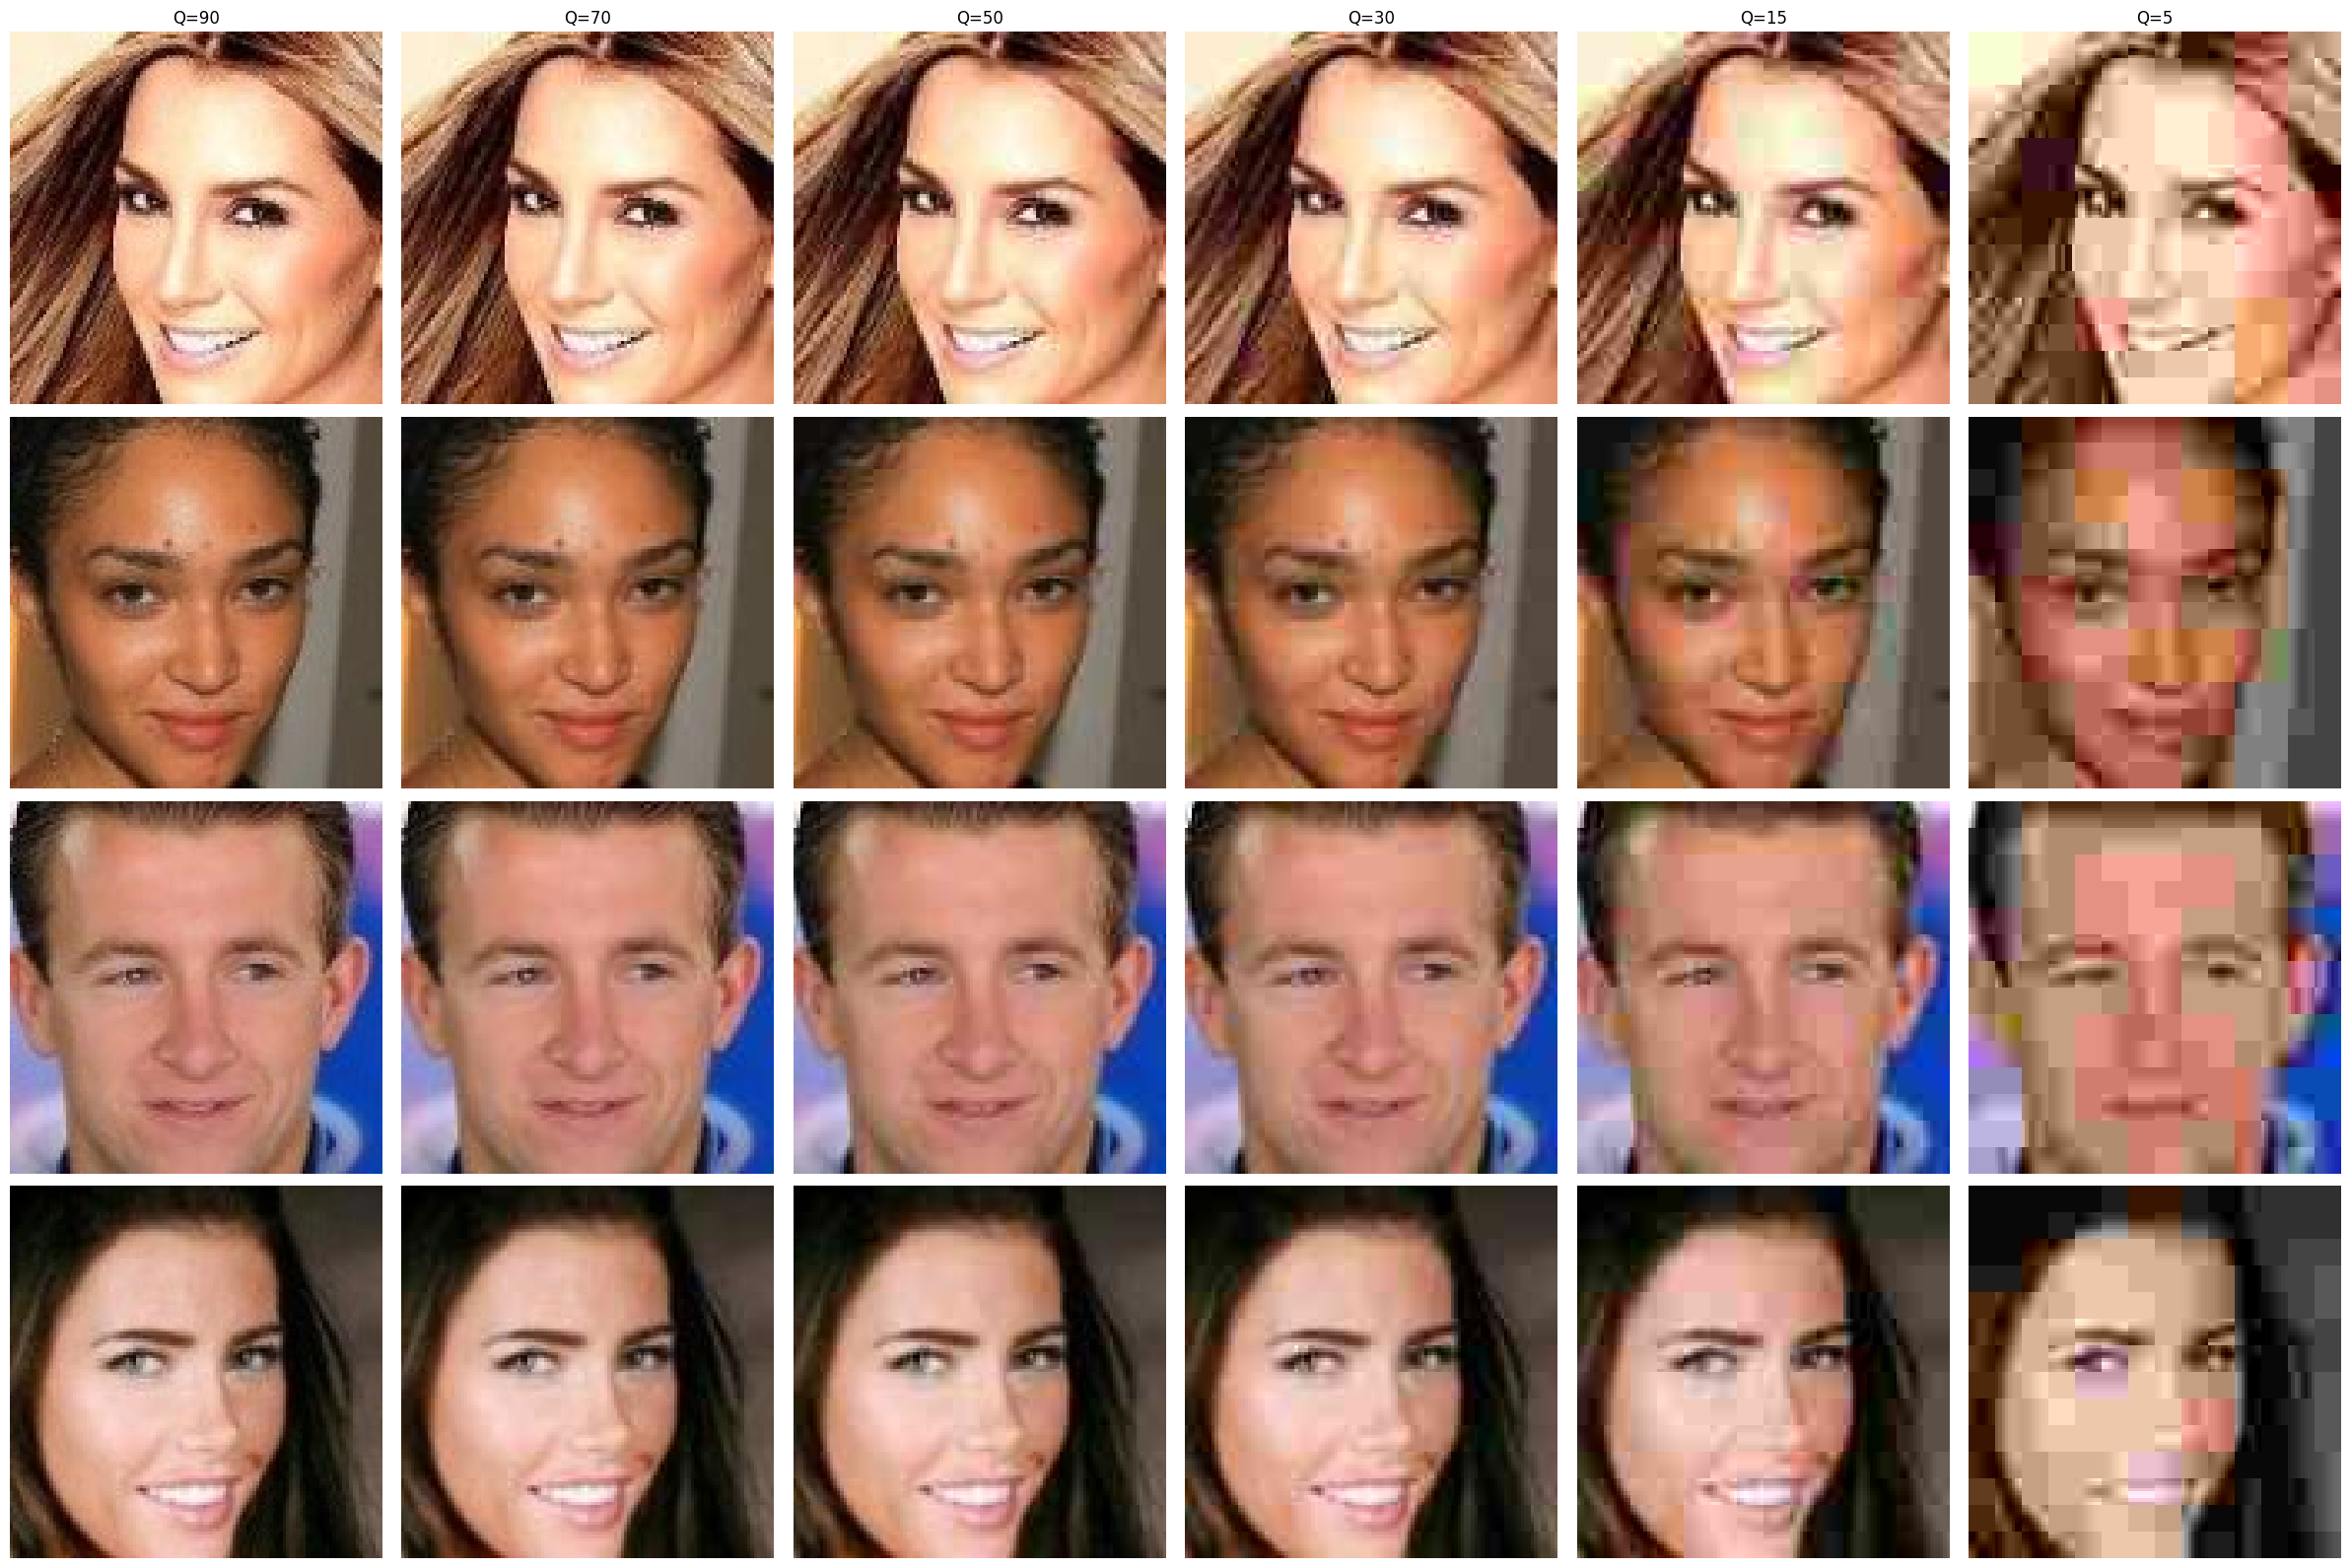

In [13]:
def show_quality_grid(image_paths, qualities):
    n_rows = len(image_paths)
    n_cols = len(qualities)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

    if n_rows == 1:
        axes = [axes]
    if n_cols == 1:
        axes = [[ax] for ax in axes]

    for i, path in enumerate(image_paths):
        original_img = Image.open(path).convert("RGB")

        for j, q in enumerate(qualities):
            compressed = jpeg_compress(path, q)

            axes[i][j].imshow(compressed)
            axes[i][j].axis("off")

            if i == 0:
                axes[i][j].set_title(f"Q={q}")

        axes[i][0].set_ylabel(f"Image {i+1}", rotation=90, size=12)

    plt.tight_layout()
    plt.show()

filepaths = [IMG_DIR / images[0] for images in list(identity_to_files.values())[:4]]
qualities = [90, 70, 50, 30, 15, 5]
show_quality_grid(filepaths, qualities)
#filepaths

In [14]:
def get_embedding_with_compression(model, img_path, quality):
    img = jpeg_compress(img_path, quality)
    return get_embedding_from_pil(model, img)

In [ ]:
qualities = [90, 70, 50, 30, 15, 5]
for quality in qualities:

    # Positive pairs
    positive_scores = []
    
    for identity, files in tqdm(identity_to_files.items(), desc="Positive pairs"):
        if len(files) < 2:
            continue
        for i in range(len(files)):
            for j in range(i + 1, min(i+2, len(files))):
                emb1 = get_embedding_with_compression(model, IMG_DIR / files[i], quality=quality)
                emb2 = get_embedding_with_compression(model, IMG_DIR / files[j], quality=quality)
                sim = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
                positive_scores.append(sim)

    # Negative pairs
    negative_scores = []

    for f1, f2 in fixed_negative_pairs:
        emb1 = get_embedding_with_compression(model, IMG_DIR / f1, quality=quality)
        emb2 = get_embedding_with_compression(model, IMG_DIR / f2, quality=quality)
        sim = F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
        negative_scores.append(sim)

    with open(f'far_frr_jpeg_analysis_{quality}.json', 'w') as f:
        json.dump({
            'positive_scores': positive_scores,
            'negative_scores': negative_scores
        }, f)

Positive pairs: 100%|██████████| 1402/1402 [06:32<00:00,  3.57it/s]


In [25]:
quality_results = {}

for quality in [5, 15, 30, 50, 70, 90]:
    filename = f"far_frr_jpeg_analysis_{quality}.json"
    with open(filename, 'r') as f:
        quality_results[quality] = json.load(f)

with open('far_frr_analysis.json', 'r') as f:
    quality_results[100] = json.load(f)

In [26]:
thresholds = np.linspace(-1, 1, 200)

In [27]:
for quality, results in quality_results.items():
    
    far_list = []
    frr_list = []
    
    for t in thresholds:
        FAR = np.mean([s >= t for s in results['negative_scores']])
        FRR = np.mean([s < t for s in results['positive_scores']])
        
        far_list.append(FAR)
        frr_list.append(FRR)

    results['far_list'] = far_list
    results['frr_list'] = frr_list
    

In [28]:
for quality, results in quality_results.items():
    diff = np.abs(np.array(results['far_list']) - np.array(results['frr_list']))
    eer_index = np.argmin(diff)
    results['eer_index'] = eer_index

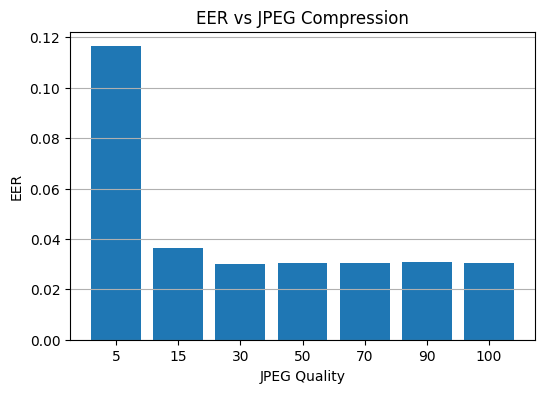

In [29]:
eers = []
qualities = []

for quality, results in quality_results.items():
    eer_idx = results['eer_index']
    eer = results['far_list'][eer_idx]
    
    qualities.append(quality)
    eers.append(eer)

plt.figure(figsize=(6, 4))
plt.bar([str(q) for q in qualities], eers)

plt.xlabel("JPEG Quality")
plt.ylabel("EER")
#plt.ylim(0.0, 0.038)
plt.title("EER vs JPEG Compression")
plt.grid(axis='y')

plt.show()

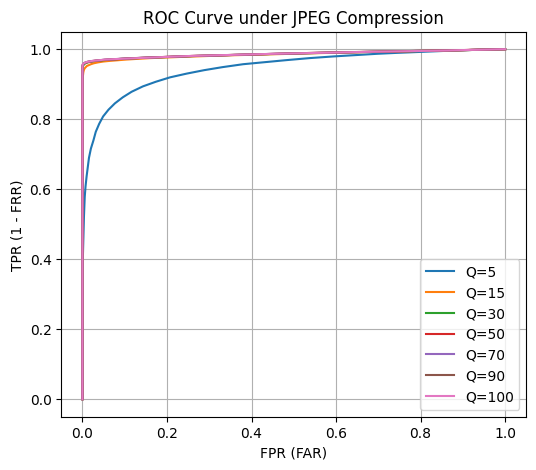

In [30]:
plt.figure(figsize=(6, 5))

for quality, results in quality_results.items():
    fpr = results["far_list"]
    tpr = [1 - f for f in results["frr_list"]]

    plt.plot(fpr, tpr, label=f"Q={quality}")

plt.xlabel("FPR (FAR)")
plt.ylabel("TPR (1 - FRR)")
plt.title("ROC Curve under JPEG Compression")
plt.grid()
plt.legend()

plt.show()

In [31]:
for quality, results in quality_results.items():
    fpr = results["far_list"]
    tpr = [1 - f for f in results["frr_list"]]
    roc_auc = auc(fpr, tpr)
    results['roc_auc'] = roc_auc

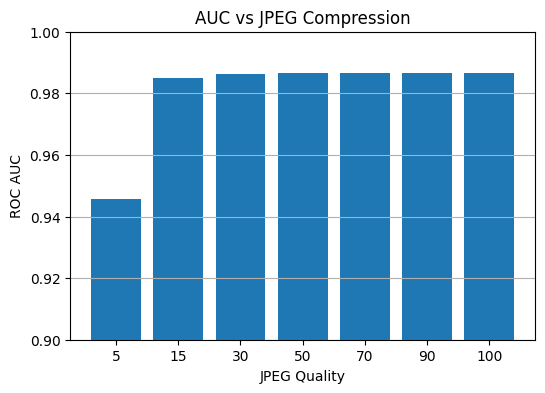

In [33]:
qualities = []
aucs = []

for quality, results in quality_results.items():
    qualities.append(quality)
    aucs.append(results["roc_auc"])

plt.figure(figsize=(6, 4))
plt.bar([str(q) for q in qualities], aucs)

plt.xlabel("JPEG Quality")
plt.ylabel("ROC AUC")
plt.ylim(0.9, 1)
plt.title("AUC vs JPEG Compression")
plt.grid(axis='y')

plt.show()

In [34]:
for quality, results in quality_results.items():

    fpr = results["far_list"]
    tpr = [1 - f for f in results["frr_list"]]
    
    tpr = np.array(tpr)
    fpr = np.array(fpr)
    
    # distance to (0, 1)
    dist = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)
    
    best_idx = np.argmin(dist)
    
    results['roc_best_fpr'] = fpr[best_idx]
    results['roc_best_tpr'] = tpr[best_idx]

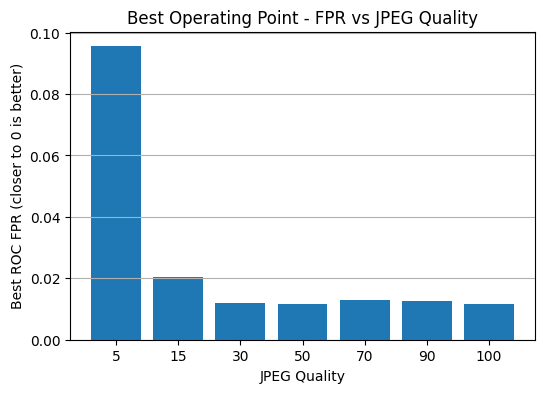

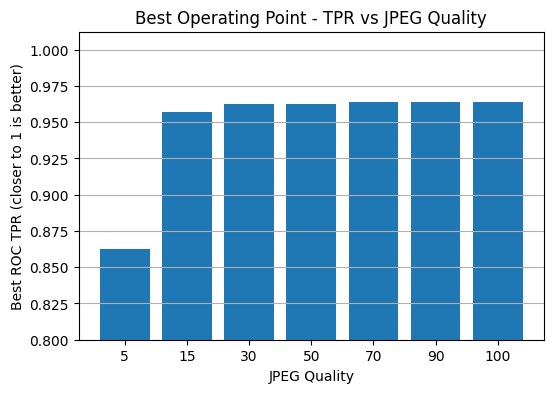

In [36]:
qualities = []
best_fprs = []
best_tprs = []

for quality, results in quality_results.items():
    qualities.append(quality)
    best_fprs.append(results["roc_best_fpr"])
    best_tprs.append(results["roc_best_tpr"])

pairs = sorted(zip(qualities, best_fprs), reverse=False)

q_sorted = [str(q) for q, _ in pairs]
fpr_sorted = [v for _, v in pairs]

plt.figure(figsize=(6, 4))
plt.bar(q_sorted, fpr_sorted)

plt.xlabel("JPEG Quality")
plt.ylabel("Best ROC FPR (closer to 0 is better)")
plt.title("Best Operating Point - FPR vs JPEG Quality")
plt.grid(axis='y')

plt.show()

pairs = sorted(zip(qualities, best_tprs), reverse=False)

q_sorted = [str(q) for q, _ in pairs]
tpr_sorted = [v for _, v in pairs]

plt.figure(figsize=(6, 4))
plt.bar(q_sorted, tpr_sorted)

plt.xlabel("JPEG Quality")
plt.ylabel("Best ROC TPR (closer to 1 is better)")
plt.title("Best Operating Point - TPR vs JPEG Quality")
plt.ylim(0.8)
plt.grid(axis='y')

plt.show()

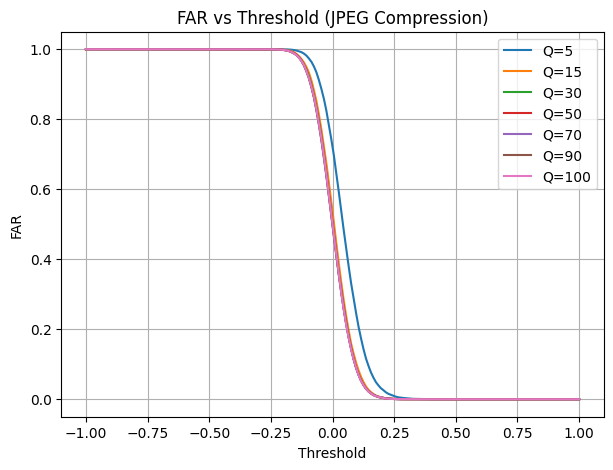

In [37]:
plt.figure(figsize=(7, 5))

for quality, results in quality_results.items():
    plt.plot(thresholds, results["far_list"], label=f"Q={quality}")

plt.xlabel("Threshold")
plt.ylabel("FAR")
plt.title("FAR vs Threshold (JPEG Compression)")
plt.grid()
plt.legend()

plt.show()

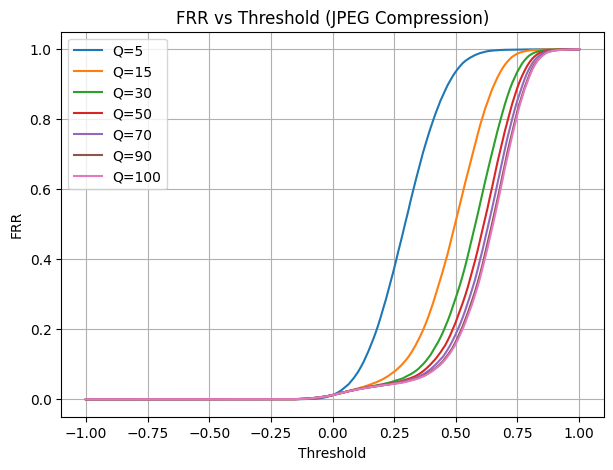

In [38]:
plt.figure(figsize=(7, 5))

for quality, results in quality_results.items():
    plt.plot(thresholds, results["frr_list"], label=f"Q={quality}")

plt.xlabel("Threshold")
plt.ylabel("FRR")
plt.title("FRR vs Threshold (JPEG Compression)")
plt.grid()
plt.legend()

plt.show()